Best MIS size: 8
Violations (must be 0): 0.0
Best x (1=selected): [0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0]
p_mean: 0.03635338321328163 p_max: 0.06883559376001358 p_min: 0.030337264761328697


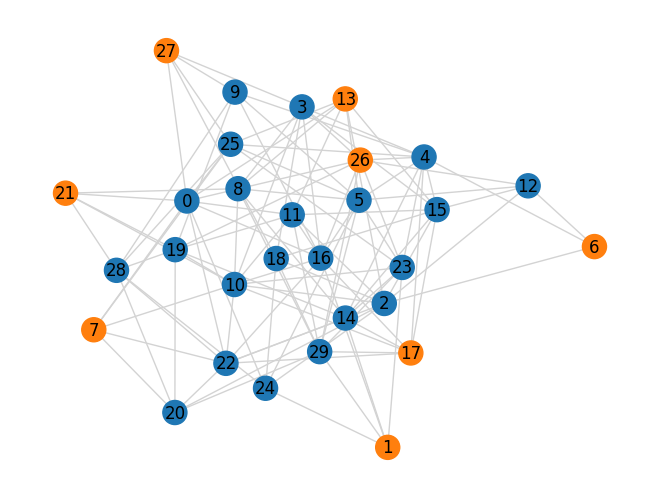

In [3]:
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1):
    return nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)

def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    np.fill_diagonal(W, 0.0)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W

def draw_graph_with_mis(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    node_colors = ["tab:orange" if x[i] == 1 else "tab:blue" for i in G.nodes()]

    # highlight violations (should be none)
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("red" if (x[u] == 1 and x[v] == 1) else "lightgray")

    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors)
    plt.show()

def S_bernoulli(p, eps=1e-12):
    p = p.clamp(eps, 1 - eps)
    return -(p * p.log() + (1 - p) * (1 - p).log()).sum(1)

def mis_energy(W, p, A=10.0, B=1.0):
    viol = ((p @ W) * p).sum(1) / 2.0
    size = p.sum(1)
    return A * viol - B * size

def greedy_repair_mis_from_probs(G, p_vec):
    order = np.argsort(-p_vec)  # descending p
    blocked = set()
    x = np.zeros(len(p_vec), dtype=np.int32)

    for i in order:
        if i in blocked:
            continue
        x[i] = 1
        blocked.add(i)
        for nb in G.neighbors(i):
            blocked.add(nb)
    return x

def count_violations(W_np, x):
    x = x.astype(np.float32)
    return float(((x @ W_np) * x).sum() / 2.0)

def solve_mis(G, W_np_or_torch, batch=64, lr=0.05, steps=400, A=10.0, B=1.0, beta_min=0.5, beta_max=20.0):
    device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

    W = W_np_or_torch
    if not torch.is_tensor(W):
        W = torch.tensor(W, dtype=torch.float32)
    W = W.to(device)

    n = W.shape[0]
    h = torch.nn.Parameter(torch.zeros(batch, n, device=device))
    opt = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(beta_min, beta_max, steps=steps).to(device)

    for beta in beta_range:
        p = torch.sigmoid(h)
        Fval = mis_energy(W, p, A=A, B=B) - S_bernoulli(p) / beta
        opt.zero_grad()
        Fval.sum().backward()
        opt.step()

    # Probabilities for each replica
    p_np = torch.sigmoid(h).detach().cpu().numpy()  # (batch,n)

    best_x = None
    best_size = -1
    best_viol = None

    # pick best valid independent set by greedy repair
    for r in range(batch):
        xr = greedy_repair_mis_from_probs(G, p_np[r])
        size = int(xr.sum())
        viol = count_violations(W_np_or_torch if not torch.is_tensor(W_np_or_torch) else W_np_or_torch.detach().cpu().numpy(), xr)
        if viol != 0:
            continue
        if size > best_size:
            best_size = size
            best_x = xr
            best_viol = viol

    # diagnostics
    p_mean = float(p_np.mean())
    p_max = float(p_np.max())
    p_min = float(p_np.min())

    return {
        "best_x": best_x,
        "best_size": best_size,
        "best_violations": best_viol,
        "p_mean": p_mean,
        "p_max": p_max,
        "p_min": p_min,
    }

if __name__ == "__main__":
    n_nodes   = 30
    edge_prob = 0.25
    seed      = 11

    batch     = 64
    steps     = 400
    lr        = 0.05
    beta_min  = 0.5
    beta_max  = 20.0
    A         = 10.0
    B         = 1.0

    G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
    W = graph_to_binary_adjacency(G)

    out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)

    print("Best MIS size:", out["best_size"])
    print("Violations (must be 0):", out["best_violations"])
    print("Best x (1=selected):", out["best_x"])
    print("p_mean:", out["p_mean"], "p_max:", out["p_max"], "p_min:", out["p_min"])

    draw_graph_with_mis(G, out["best_x"])